# Unidad 3 — Actividad 1: Taller de EDA y Visualización
## Proyecto MindTrack
## Análisis exploratorio preliminar del dataset limpia

#### Equipo: Nicoll y Valentina
#### Fuente: Student Depression Dataset — dataset limpio de la Unidad 2


Objetivo: realizar un análisis exploratorio preliminar del dataset limpio obtenido en la Unidad 2, mediante estadísticos descriptivos, análisis de valores faltantes y visualizaciones que permitan identificar patrones iniciales relacionados con la variable objetivo Depression.

## 0. Configuración del entorno y carga del dataset limpio

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### 0.1 Carga portable del dataset limpio

Esta celda busca el CSV **procesado** (no el crudo) en varias rutas posibles.

In [ ]:
from google.colab import files
from pathlib import Path
import pandas as pd

# Seleccionar el archivo desde tu computador
archivos = files.upload()

# Obtener el nombre del archivo subido
nombre_archivo = next(iter(archivos))

# Cargar la base de datos
ruta_dataset = Path(nombre_archivo)

df = pd.read_csv(ruta_dataset)

print(f"Dataset limpio encontrado en: {ruta_dataset.resolve()}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

df.head()


Saving student_depression_clean.csv to student_depression_clean.csv
Dataset limpio encontrado en: /content/student_depression_clean.csv
Filas: 27,901 | Columnas: 31


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,...,Gender_bin,City_freq,Degree_freq,Age_norm,CGPA_norm,Work/Study Hours_norm,Academic Pressure_norm,Financial Stress_norm,Study Satisfaction_norm,Age_group
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,...,1,0.034730,0.029031,1.463165,0.893393,-1.121213,1.345543,-1.488873,-0.693425,30+
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,...,0,0.027490,0.031827,-0.371474,-1.194076,-1.121213,-0.826104,-0.793160,1.510636,20-25
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,...,1,0.049174,0.021505,1.055467,-0.425724,0.497095,-0.102222,-1.488873,1.510636,30+
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,...,0,0.024551,0.051360,0.443921,-1.404862,-0.851495,-0.102222,1.293981,-0.693425,26-30
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,...,0,0.037131,0.036630,-0.167625,0.322229,-1.660650,0.621660,-1.488873,0.041262,20-25


## 1. Recordatorio: pregunta e hipótesis del Entregable 1

**Pregunta analítica central:** ¿Qué tan bien puede un modelo de clasificación estimar el
riesgo de depresión de un estudiante universitario a partir de variables académicas,
personales y socioeconómicas?

**Hipótesis analítica de partida (Entregable 1):** las variables de presión académica, estrés
financiero, satisfacción con los estudios y antecedentes personales/familiares están asociadas
de forma relevante con el riesgo de depresión, y un modelo de clasificación supervisada puede
aprovechar esas relaciones para estimarlo con un desempeño útil.

El EDA de este notebook evalúa si esta hipótesis se sostiene, se refina o se modifica —
ver la Sección 5.


## 2. Estadísticos descriptivos de todas las variables clave

Antes de visualizar, dejamos la descripción numérica completa — es el insumo de la sección
'estadísticos descriptivos' que exige el entregable de la Unidad 3.


In [ ]:
variables_numericas = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                        'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
                        'Financial Stress']

df[variables_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Financial Stress,27901.0,3.140067,1.437399,1.0,2.00,3.00,4.00,5.0


In [ ]:
variables_categoricas_clave = ['Gender', 'Sleep Duration', 'Dietary Habits',
                                'Have you ever had suicidal thoughts ?',
                                'Family History of Mental Illness']

for col in variables_categoricas_clave:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3) * 100)
    print()


--- Gender ---
Gender
Male      55.7
Female    44.3
Name: proportion, dtype: float64

--- Sleep Duration ---
Sleep Duration
Less than 5 hours    29.8
7-8 hours            26.3
5-6 hours            22.2
More than 8 hours    21.7
Others                0.1
Name: proportion, dtype: float64

--- Dietary Habits ---
Dietary Habits
Unhealthy    37.0
Moderate     35.6
Healthy      27.4
Others        0.0
Name: proportion, dtype: float64

--- Have you ever had suicidal thoughts ? ---
Have you ever had suicidal thoughts ?
Yes    63.3
No     36.7
Name: proportion, dtype: float64

--- Family History of Mental Illness ---
Family History of Mental Illness
No     51.6
Yes    48.4
Name: proportion, dtype: float64



### 2.1 Reporte de valores faltantes (verificación sobre el dataset ya limpio)

In [ ]:
reporte_nulos = pd.DataFrame({
    'valores_faltantes': df.isna().sum(),
    '% faltantes': (df.isna().mean() * 100).round(2),
})
print(reporte_nulos[reporte_nulos['valores_faltantes'] > 0])
if reporte_nulos['valores_faltantes'].sum() == 0:
    print("✔ No hay valores faltantes — confirma que el dataset de la Unidad 2 quedó bien limpio.")


Empty DataFrame
Columns: [valores_faltantes, % faltantes]
Index: []
✔ No hay valores faltantes — confirma que el dataset de la Unidad 2 quedó bien limpio.


## 3. Visualizaciones — Actividad 1 (mínimo 6) y Actividad 2 (mínimo 8)

Cada visualización va acompañada de **dos interpretaciones separadas**, tal como exige la
Actividad 2 de la guía: una **técnica** (qué muestra el gráfico en términos estadísticos) y una
**de negocio** (qué significa esto para Bienestar Universitario).


### Visualización 1 — Histograma: Academic Pressure

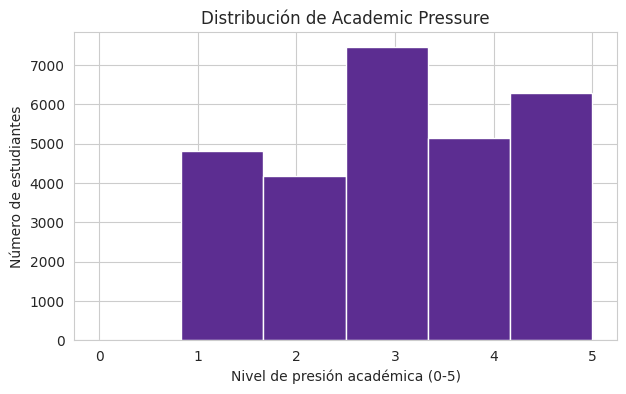

In [ ]:
plt.figure(figsize=(7,4))
df['Academic Pressure'].hist(bins=6, color='#5C2D91', edgecolor='white')
plt.title('Distribución de Academic Pressure')
plt.xlabel('Nivel de presión académica (0-5)')
plt.ylabel('Número de estudiantes')
plt.show()


**Interpretación técnica:** la distribución está concentrada en los niveles medios-altos
(3 a 5), con relativamente pocos estudiantes reportando presión académica baja.

**Interpretación de negocio:** la mayoría de los estudiantes de la muestra experimenta niveles
considerables de presión académica — Bienestar Universitario no estaría ante un problema
marginal, sino ante una condición generalizada en la población estudiantil.

### Visualización 2 — Histograma: Financial Stress

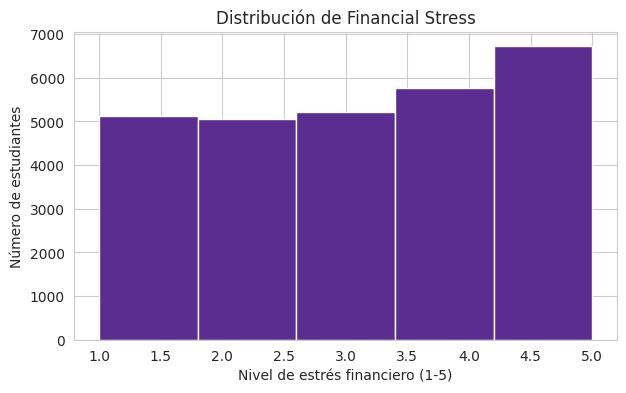

In [ ]:
plt.figure(figsize=(7,4))
df['Financial Stress'].hist(bins=5, color='#5C2D91', edgecolor='white')
plt.title('Distribución de Financial Stress')
plt.xlabel('Nivel de estrés financiero (1-5)')
plt.ylabel('Número de estudiantes')
plt.show()


**Interpretación técnica:** la distribución es relativamente uniforme entre niveles 1 y 5,
sin una concentración dominante en un extremo.

**Interpretación de negocio:** el estrés financiero no es un problema exclusivo de un
subgrupo pequeño — está distribuido a lo largo de toda la población, lo que sugiere que las
estrategias de apoyo financiero de la universidad deberían tener alcance amplio, no focalizado.

### Visualización 3 — Boxplot: Financial Stress según Depression

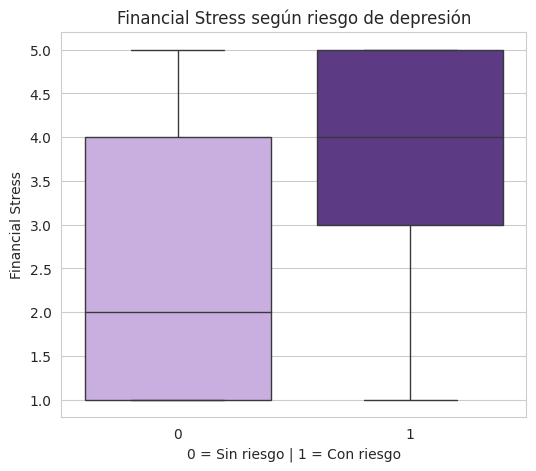

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Depression', y='Financial Stress', data=df, hue='Depression',
            palette=['#C9A6E8', '#5C2D91'], legend=False)
plt.title('Financial Stress según riesgo de depresión')
plt.xlabel('0 = Sin riesgo | 1 = Con riesgo')
plt.show()


**Interpretación técnica:** la mediana de Financial Stress es visiblemente más alta en el
grupo con Depression=1, con menor dispersión hacia niveles bajos.

**Interpretación de negocio:** el estrés financiero está asociado con el riesgo de depresión —
esto respalda directamente la hipótesis del Entregable 1 sobre el peso de esta variable.

### Visualización 4 — Boxplot: Academic Pressure según Depression

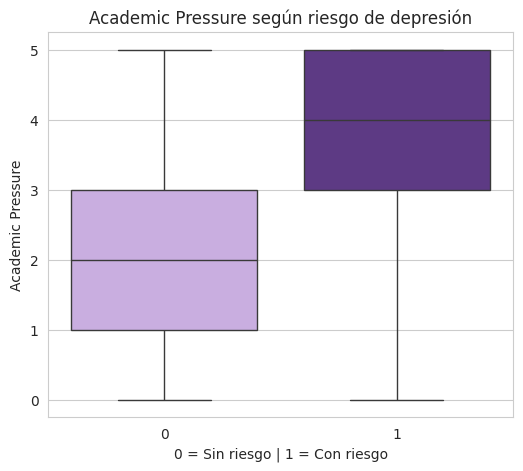

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Depression', y='Academic Pressure', data=df, hue='Depression',
            palette=['#C9A6E8', '#5C2D91'], legend=False)
plt.title('Academic Pressure según riesgo de depresión')
plt.xlabel('0 = Sin riesgo | 1 = Con riesgo')
plt.show()


**Interpretación técnica:** el patrón es similar al de Financial Stress: la mediana de
presión académica es mayor en el grupo con riesgo de depresión.

**Interpretación de negocio:** confirma que la carga académica percibida es un factor asociado
al riesgo, no solo una molestia reportada de forma aislada.

### Visualización 5 — Scatter plot: Academic Pressure vs. Financial Stress, coloreado por Depression

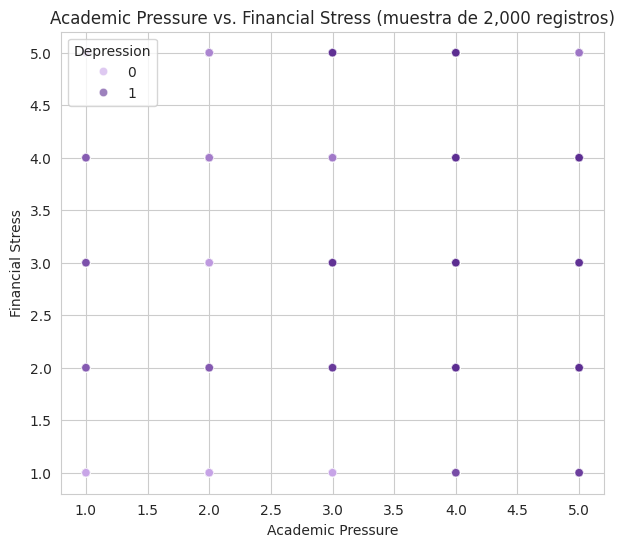

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(x='Academic Pressure', y='Financial Stress', hue='Depression',
                 data=df.sample(2000, random_state=42), palette=['#C9A6E8', '#5C2D91'], alpha=0.6)
plt.title('Academic Pressure vs. Financial Stress (muestra de 2,000 registros)')
plt.show()


**Interpretación técnica:** no hay una separación perfectamente lineal entre clases, pero
se observa mayor densidad de puntos morados (Depression=1) en la esquina superior derecha
(presión académica y estrés financiero altos simultáneamente).

**Interpretación de negocio:** el riesgo más alto no depende de un solo factor, sino de la
combinación de presión académica y estrés financiero — un programa de bienestar que solo
atienda una de las dos dimensiones dejaría casos sin cubrir.

### Visualización 6 — Matriz de correlación

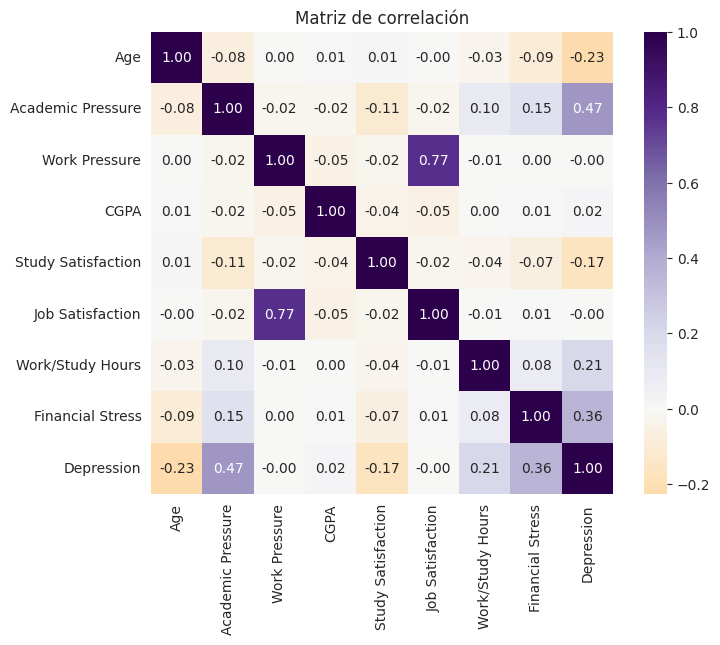

In [ ]:
variables_corr = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                   'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
                   'Financial Stress', 'Depression']

matriz_corr = df[variables_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='PuOr', center=0, square=True)
plt.title('Matriz de correlación')
plt.show()


**Interpretación técnica:** Academic Pressure y Financial Stress muestran la correlación
positiva más fuerte con Depression entre las variables numéricas; Study Satisfaction muestra
correlación negativa (a mayor satisfacción, menor riesgo).

**Interpretación de negocio:** estas tres variables son las palancas más claras: aumentar la
satisfacción con los estudios y reducir la percepción de presión/estrés podría tener el mayor
impacto potencial sobre el riesgo, según lo que muestran los datos.

## Hallazgos preliminares
1. Presión académica y depresión.
Se observa una diferencia en la distribución de la presión académica entre estudiantes con y sin depresión. Esto sugiere que la presión académica es una variable relevante para continuar explorando su asociación con la variable objetivo.
2. Estrés financiero y depresión.
La distribución de Financial Stress presenta diferencias según la condición de depresión. Este comportamiento indica que el estrés financiero puede aportar información relevante para el análisis del riesgo de depresión.
3. Relación entre presión académica y estrés financiero.
El gráfico de dispersión permite observar una relación entre ambas variables, aunque no necesariamente fuerte. Esto resulta relevante porque ambas representan factores asociados al contexto académico y socioeconómico del estudiante.
4. Relación entre variables explicativas.
La matriz de correlaciones permite identificar asociaciones entre algunas de las variables analizadas y ayuda a reconocer cuáles podrían ser más relevantes para las siguientes etapas del proyecto.
5. Confirmación preliminar de la hipótesis.
En conjunto, los resultados preliminares son consistentes con la hipótesis inicial, ya que muestran asociaciones entre factores académicos y socioeconómicos y la variable Depression. Sin embargo, estos resultados son exploratorios y no permiten establecer relaciones causales.

## Conclusión del EDA preliminar

El análisis exploratorio permitió obtener una primera caracterización del dataset limpio y reconocer patrones asociados con la variable objetivo Depression. Los resultados muestran que variables como la presión académica y el estrés financiero presentan comportamientos que justifican su consideración en las siguientes etapas del proyecto.
Los hallazgos preliminares son coherentes con la hipótesis planteada inicialmente, aunque no permiten establecer causalidad. Por esta razón, los resultados obtenidos serán utilizados como punto de partida para profundizar el análisis en la siguiente actividad, ampliar las visualizaciones y refinar la hipótesis analítica.